In [1]:
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import bootstrap
import matplotlib.pyplot as plt
import statsmodels.api as sm
np.set_printoptions(legacy='1.21')

# Ejercicio
**Estimar cambio de peso promedio en mujeres con anorexia**

Un estudio experimental comparó 3 terapias para mujeres jóvenes que sufren de anorexia. Para cada una, el peso fue medido antes y después de un periodo fijo de tratamiento diseñado para ayudar a ganar peso.

In [2]:
data = pd.read_csv('Anorexia.dat', sep='\\s+')
data.head()

,subject,therapy,before,after
0,1,cb,80.5,82.2
1,2,cb,84.9,85.6
2,3,cb,81.5,81.4
3,4,cb,82.6,81.9
4,5,cb,79.9,76.4


- Calcula la diferencia de peso antes y después del periodo de tratamiento.
- Enfócate únicamente en los datos de terapia cognitivo conductual ("cb" en la base de datos)

In [3]:
cb_data = data[data['therapy'] == 'cb']
diferencias = cb_data['after'] - cb_data['before']
diferencias

0      1.7
1      0.7
2     -0.1
3     -0.7
4     -3.5
5     14.9
6      3.5
7     17.1
8     -7.6
9      1.6
10    11.7
11     6.1
12     1.1
13    -4.0
14    20.9
15    -9.1
16     2.1
17    -1.4
18     1.4
19    -0.3
20    -3.7
21    -0.8
22     2.4
23    12.6
24     1.9
25     3.9
26     0.1
27    15.4
28    -0.7
dtype: float64

- Calcula un intervalo del 95% de confianza para la media poblacional μ, suponiendo que los datos se distribuyen normal. 
- ¿Qué es lo que observas?

In [4]:
# Intervalos de confianza usando distribución t
n = len(diferencias)
media = np.mean(diferencias)
std = np.std(diferencias, ddof=1)

t_critico_95 = stats.t.ppf(1 - 0.05/2, df=n-1)
error_95 = t_critico_95 * (std / np.sqrt(n))
ci_95 = (media - error_95, media + error_95)

print("Intervalos usando distribución t:")
print(f"95% CI: {ci_95}")

Intervalos usando distribución t:
95% CI: (0.2268901583587768, 5.7869029450894995)


El intervalo del 95% es totalmente positivo, lo que sugiere que, con un 95% de confianza, la terapia cb genera una ganancia de peso promedio entre +0.23 kg y +5.79 kg.

- Calcula ahora un intervalo del 99% de confianza y compáralo con el anterior. Explica lo que encuentras.
- Realiza un histograma de la diferencia de peso en el caso cognitivo conductual. ¿Qué es lo que encuentras?

In [5]:
t_critico_99 = stats.t.ppf(1 - 0.01/2, df=n-1)
error_99 = t_critico_99 * (std / np.sqrt(n))
ci_99 = (media - error_99, media + error_99)

print("Intervalos usando distribución t:")
print(f"95% CI: {ci_95}")
print(f"99% CI: {ci_99}")

Intervalos usando distribución t:
95% CI: (0.2268901583587768, 5.7869029450894995)
99% CI: (-0.7432794440477513, 6.757072547496028)


El intervalo del 99% incluye valores negativos (-0.74 kg), indicando que, con mayor confianza (99%), no podemos descartar que algunos pacientes podrían no ganar peso o incluso perderlo.

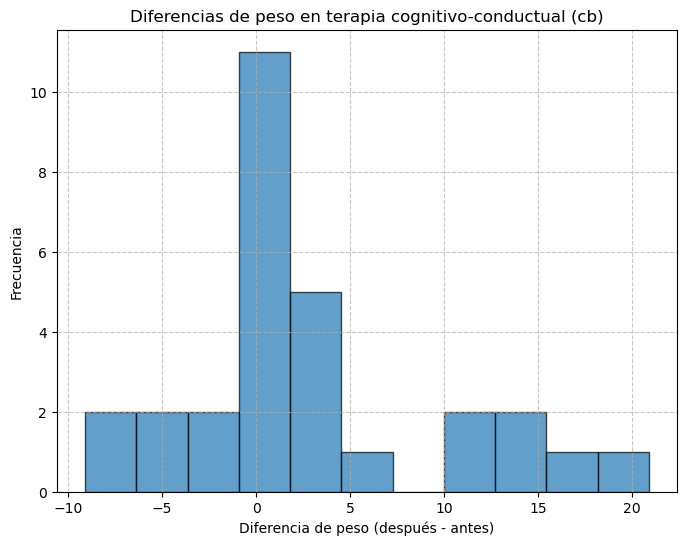

In [6]:
plt.figure(figsize=(8, 6))
plt.hist(diferencias, bins='auto', edgecolor='black', alpha=0.7, color='#1f77b4')
plt.title('Diferencias de peso en terapia cognitivo-conductual (cb)')
plt.xlabel('Diferencia de peso (después - antes)')
plt.ylabel('Frecuencia')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Tenemos valores muy altos de ganancia de peso y la cola izquierda parece menos pronunciada. Parece dificil sugerir que la distribucion es normal.

- Finalmente calcula un intervalo de confianza bootstrap para los datos y compáralo con los dos intervalos anteriores.

In [7]:
rng = np.random.default_rng(42)

res_bootstrap_95 = bootstrap(data=(diferencias,), statistic=np.mean, 
                            confidence_level=0.95, method='percentile',
                            random_state=rng)

res_bootstrap_99 = bootstrap(data=(diferencias,), statistic=np.mean,
                            confidence_level=0.99, method='percentile',
                            random_state=rng)

print("\nIntervalos bootstrap:")
print(f"Bootstrap 95% CI: {res_bootstrap_95.confidence_interval}")
print(f"Bootstrap 99% CI: {res_bootstrap_99.confidence_interval}")


Intervalos bootstrap:
Bootstrap 95% CI: ConfidenceInterval(low=0.4793103448275879, high=5.72758620689655)
Bootstrap 99% CI: ConfidenceInterval(low=-0.24486206896551738, high=6.5241724137931065)


El bootstrap 95% es más estrecho y desplazado hacia valores positivos, reforzando la idea de que la terapia tiene un efecto positivo consistente en la mayoría de los pacientes

El bootstrap 99% también es más ajustado reduciendo el rango de posibles pérdidas

Los datos no normales afectan más a los intervalos basados en t. El bootstrap, al no asumir normalidad, ofrece una estimación más realista de la variabilidad